# 다이캐스팅 공정 데이터 기반 품질 예측 프로젝트

- 다이캐스팅은 용융 금속을 금형에 고압으로 주입하여 정밀한 제품을 생산하는 공정이다.
- 생산 효율을 높이고 불량품을 낮추기 위해 공정 변수 및 센서 데이터를 분석해서 불량 유형을 자동 예측하는 머신러닝 모델을 개발해야함.
- 실시간 공정 데이터와 품질 검사를 연계하여 품질 예측 시스템을 구축하고자 함.

# 비즈니스 문제 정의

### 현재 상황

- 불량품이 발생해도 육안 검사에 의존하여 판정 기준의 주관성과 검사 속도의 한계로 생산성이 저하됨.
- 불량 발생 원인을 추적하기 힘들어 공정 개선 및 문제 해결이 어려움.
- 공정 데이터와 품질 검사를 효과적으로 매핑하지 못하여 실시간 품질 관리 및 재발 방지 대책이 부족한 상황.

### 분석 목표

- 다이캐스팅 공정 과정에서 발생하는 다양한 불량 유형을 자동으로 예측해주는 머신 러닝 모델 개발
- 공정 데이터와 센서 데이터를 면밀히 분석해 불량 여부와의 관계성 파악
- 불량 발생의 주요 원인을 분석해서 공정의 최적화를 지원
- 실시간 품질 예측 체계를 구축하여 조기 경보 시스템 도입 및 불량률 감소

### 비즈니스 산출물

1) 불량 발생의 주요 원인을 분석하고 이를 시각화하여 제시
2) 불량 유형을 자동으로 예측해주는 머신러닝 모델 제시

# 데이터셋 구성

- **공정(Process)데이터**
1) Shot ID : 주조 샷 고유 식별자
2) Injection Speed : 용탕 주입 속도 (m/s)
3) Die Temperature : 금형 온도
4) Casting Pressure : 주조 압력 (bar)
5) Cooling Time: 냉각 시간 (s)

- **센서(Sensor) 데이터**
1) Mold Temp Sensor : 금형 내 센서 온도 (°C)
2) Hydraulic Pressure : 유압 압력 (bar)
3) Vibration Sensor : 진동값 (Hz)
4) Flow Rate Sensor : 유량 (L/min)

- **불량(Defects) 데이터**
1) Defect Type : 발생한 불량 유형 (미성형, 박리, 기공, 평탄, 개재물 등)
2) Defect Status : 양품(0) / 불량(1) 여부

In [1]:
# ============================================================
# 공정(Process) 주요 컬럼 설명
# ============================================================
# • Shot ID                       : 주조 번호 (붕어빵 틀에 반죽을 한 번 붓고 뚜껑을 닫는 행위에 관한 일련번호)
# • Injection Speed               : 주입 속도 (쇳물을 금형에 얼마나 빨리 밀어 넣는가)
# • Die Temperature               : 금형 온도 (금형 틀이 어느정도의 온도인가)
# • Casting Pressure              : 주조 압력 (쇳물을 다 채운 뒤 강하게 누르는 힘)
# • Cooling Time                  : 냉각 시간 (액체 상태인 금속이 고체가 될 떄까지 기다리는 힘)


# ============================================================
# 공정(Process) 컬럼별 분석 관점
# ============================================================
# • Injection Speed               : 주입 속도가 너무 느리면 쇳물이 금형으로 가다가 굳어버리고, 너무 빠르면 사방으로 튀어서 속에 공기 방울(기공)이 생길 수 있다.
# • Die Temperature               : 금형 온도가 너무 낮으면 쇳물이 일찍 굳고 너무 높으면 금형 수명이 줄거나 제품이 달라붙는 현상이 생긴다.
# • Casting Pressure              : 압력이 너무 낮으면 기공이 발생할 수 있고, 너무 높으면 금형 손상 및 제품 변형이 일어날 수 있다.
# • Cooling Time                  : 냉각 시간이 너무 짧으면 탈형 시 변형이 오고, 너무 느리면 사이클 타임이 늘어나 생산성이 떨어진다.


# ============================================================
# 센서(Sensor) 주요 컬럼 설명
# ============================================================
# • Mold Temp Sensor               : 금형 내부 온도 (Die Temperature가 전체의 겉 온도라면, 이거는 틀 안쪽 깊숙한 곳의 실시간 온도이다)
# • Hydraulic Pressure             : 유압 압력 (bar) (쇳물을 밀어내기 위해 기계 팔(실린더)이 쓰는 기름의 힘 혈압과 비슷하다고 볼 수 있음)
# • Vibration Sensor               : 진동값 (Hz) (기계가 작동할 떄의 떨림)
# • Flow Rate Sensor               : 유량 (L/min) (틀을 식히기 위한 냉각수가 흐르는 속도를 나타냄)


# ============================================================
# 센서(Sensor) 컬럼별 분석 관점
# ============================================================
# • Mold Temp Sensor               : 쇳물이 들어올 때 순간 확 올랐다가 식으면서 툭 떨어지는 경향을 보인다
# • Hydraulic Pressure             : 유압 압력은 혈압과 비슷하다고 생각할 수 있다. 유압 압력이 일정해야 쇳물을 쏘아 주는 힘이 균일해진다.
# • Vibration Sensor               : 평소보다 많이 흔들린다면 나사가 풀렸거나, 부품이 마모됐거나, 쇳물이 튀어서 어딘가 걸렸다는 신호일 수 있다.
# • Flow Rate Sensor               : 유량이 적으면 틀이 식지 않아서 제품이 녹아내릴 수 있다.


# ============================================================
# 불량(Defects) 주요 컬럼 설명
# ============================================================
# • Defect Type                   : 발생한 불량 유형
# • Defect Status                 : 양품(0) / 불량(1) 여부


# ============================================================
# 불량(Defects) 유형 설명
# ============================================================
# • 미성형 (Underfill/Short Shot)  : 반죽이 모자라 다 완성되지 못한 붕어빵 (주입 속도가 느리거나, 금형 온도가 낮을 때 주로 발생) -> Injection Speed, Mold Temp Sensor
# • 박리 (Lamination/Peeling)      : 금속 층이 서로 제대로 붙지 않고 겹쳐진 상태 (쇳물이 들어갈 때 너무 차갑거나, 불순물이 섞여 층이 생기면 발생) -> Mold Temp Sensor, Flow Rate Sensor
# • 기공 (Porosity/Gas Hole)       : 공기 방울이 송송 뚫린 상태(주조 압력이 너무 낮거나, 주입 속도가 너무 빨라서 공기가 들어갔을 때 생김) -> Casting Pressure, Injection Speed
# • 평탄 (Flatness Error)          : 바닥이 평평하지 않고 휘어진 붕어빵 (냉각 시간이 너무 짧거나, 냉각수가 골고루 잘 흐르지 못했을 때 발생) -> Cooling Time, Flow Rate Sensor
# • 개재물 (Inclusion)             : 반죽에 검은 가루나 돌멩이가 들어간 것 (재료 관리가 안되었거나, 필터에 문제가 있을 때 발생) -> Flow Rate Sensor

---
# 1.1 필요 라이브러리 및 폰트 로드

In [2]:
# ============================================================
# 라이브러리 Import
# ============================================================

# 데이터 처리 및 분석
import numpy as np
import pandas as pd
from IPython.display import display
import warnings
import platform

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

# 참고: seed 고정으로 팀원 간 동일한 결과 재현 가능
np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)


라이브러리 로드 완료!
한글 폰트 설정 완료!


# 1.2 데이터 로드

In [3]:
# 1. 원본 데이터 로드
df_original = pd.read_csv("DieCasting_Quality_Raw_Data.csv", header=[0,1])

# 제품 타입 1번 데이터 추출
df_product_1 = df_original.loc[df_original[('Process', 'Product_Type')] == 1].copy()

# 제품 타입 2번 데이터 추출
df_product_2 = df_original.loc[df_original[('Process', 'Product_Type')] == 2].copy()

# 2. 컬럼명 중 첫번째 행을 기준으로 컬럼 분리
process_cols = [col for col in df_product_2.columns if col[0] == 'Process']
sensor_cols = [col for col in df_product_2.columns if col[0] == 'Sensor']
defects_cols = [col for col in df_product_2.columns if col[0] == 'Defects']

# 3. 첫 번째 컬럼을 기준으로 분리된 데이터 프레임 생성
df_process = df_product_2[process_cols].copy()
df_sensor = df_product_2[sensor_cols].copy()
df_defects = df_product_2[defects_cols].copy()

# 4. 두 번째 행에 있는 컬럼명만 사용하도록 변경
# get_level_values(가져오고 싶은 레벨 인덱스) - level 0: 첫번째 행, level 1: 두번째 행
# 왼쪽 .columns: 컬럼명을 바꾸기 위한 설정
# 오른쪽 .columns: 기존 다중레벨 컬럼 가져오기 → get_level_values(1)로 Level 1만 추출
df_process.columns = df_process.columns.get_level_values(1)
df_sensor.columns = df_sensor.columns.get_level_values(1)
df_defects.columns = df_defects.columns.get_level_values(1)

---

# 2 데이터 전처리 (Data Preprocessing)

### 2.1 중복 데이터 확인

In [4]:
# 1. 전체 행에 대한 중복값 확인 -> 완전히 동일한 행이 있는지 확인하는 용도 -> 없음
print(f"전체 행에 대한 데이터 중복값 : {df_original.duplicated().sum()}건")

# 2. ID 기준으로 중복값 확인 -> 설비 ID 중복 확인용 -> 없음
print(f"ID 기준에 대한 중복값 : {df_process.duplicated(subset=["id"]).sum()}건")


전체 행에 대한 데이터 중복값 : 0건
ID 기준에 대한 중복값 : 0건


### 2.2 데이터 타입 확인

In [5]:
# 각 데이터 프레임별 컬럼의 데이터 형식 확인
print('='*30)
print("<Process 관련 데이터프레임 정보>")
print('='*30)
display(df_process.dtypes)

print('='*30)
print("<Sensor 관련 데이터프레임 정보>")
print('='*30)
display(df_sensor.dtypes)

print('='*30)
print("<Defects 관련 데이터프레임 정보>")
print('='*30)
display(df_defects.dtypes)

<Process 관련 데이터프레임 정보>


id                       int64
Product_Type             int64
Shot                     int64
Velocity_1             float64
Velocity_2             float64
Velocity_3             float64
High_Velocity          float64
Cylinder_Pressure        int64
Rapid_Rise_Time        float64
Biscuit_Thickness        int64
Clamping_Force           int64
Cycle_Time             float64
 Pressure_Rise_Time    float64
Casting_Pressure         int64
Spray_Time             float64
Spray_1_Time           float64
Spray_2_Time           float64
dtype: object

<Sensor 관련 데이터프레임 정보>


Melting_Furnace_Temp    float64
Air_Pressure            float64
Air_Pressure_Min          int64
Air_Pressure_Max          int64
Coolant_Temp            float64
Coolant_Temp_Min          int64
Coolant_Temp_Max          int64
Coolant_Pressure        float64
Factory_Temp            float64
Factory_Temp_Min        float64
Factory_Temp_Max        float64
Factory_Humidity        float64
Factory_Humidity_Min    float64
Factory_Humidity_Max    float64
dtype: object

<Defects 관련 데이터프레임 정보>


Short_Shot_1       int64
Bubble_1           int64
Exfoliation_1      int64
Blow_Hole_1        int64
Stain_1            int64
Dent_1             int64
Deformation_1      int64
Contamination_1    int64
Impurity_1         int64
Crack_1            int64
Scratch_1          int64
Buring_Mark_1      int64
Inclusions_1       int64
Short_Shot_2       int64
Bubble_2           int64
Exfoliation_2      int64
Blow_Hole_2        int64
Stain_2            int64
Dent_2             int64
Deformation_2      int64
Contamination_2    int64
Impurity_2         int64
Crack_2            int64
Scratch_2          int64
Buring_Mark_2      int64
Inclusions_2       int64
dtype: object

### 2.3 컬럼 정제

In [6]:
# 1. 공백 제거 및 컬럼명 소문자 통일
df_process.columns = df_process.columns.astype("str").str.strip().str.lower()
df_sensor.columns = df_sensor.columns.astype("str").str.strip().str.lower()
df_defects.columns = df_defects.columns.astype("str").str.strip().str.lower()

In [7]:
# 2. Sensor 데이터프레임에서 _min/_max로 끝나는 컬럼 찾아서 삭제
minmax_cols = [c for c in df_sensor.columns if c.endswith("_min") or c.endswith("_max")]
df_sensor_clean = df_sensor.drop(columns=minmax_cols)


print("삭제한 _min/_max 컬럼 수:", len(minmax_cols))
print("삭제 전 df_sensor shape:", df_sensor.shape)
print("삭제 후 df_sensor shape:", df_sensor_clean.shape)

삭제한 _min/_max 컬럼 수: 8
삭제 전 df_sensor shape: (3328, 14)
삭제 후 df_sensor shape: (3328, 6)


### 2.4 불량 유형 고유값 처리

In [8]:
# 1. 1(고장)이 아닌 유형의 값이 존재하는 컬럼
target_columns = [
    "short_shot_1", "exfoliation_1", "blow_hole_1", "stain_1", "deformation_1",
    "short_shot_2", "bubble_2", "exfoliation_2", "blow_hole_2", "deformation_2"
]
# 2. 1보다 큰 값을 모두 1로 변환
df_defects[target_columns] = df_defects[target_columns].clip(upper=1)

# 3. 결과 확인 <- 모든 컬럼의 고유값이 [0, 1]로 정리되었는지 확인용
print("<1보다 큰 값은 1로 변환한 후, 고유값 확인>")
for col in df_defects:
    print(f"{col}: {df_defects[col].unique()}")

<1보다 큰 값은 1로 변환한 후, 고유값 확인>
short_shot_1: [0 1]
bubble_1: [0 1]
exfoliation_1: [0]
blow_hole_1: [0 1]
stain_1: [0 1]
dent_1: [0 1]
deformation_1: [0]
contamination_1: [0 1]
impurity_1: [0 1]
crack_1: [0 1]
scratch_1: [0 1]
buring_mark_1: [0 1]
inclusions_1: [0]
short_shot_2: [0 1]
bubble_2: [0]
exfoliation_2: [0]
blow_hole_2: [0 1]
stain_2: [0]
dent_2: [0 1]
deformation_2: [0]
contamination_2: [0 1]
impurity_2: [0 1]
crack_2: [0 1]
scratch_2: [0]
buring_mark_2: [0]
inclusions_2: [0 1]


In [9]:
# 4. Cavity 1,2 불량 유형 통합
df_defects_clean =df_defects.copy()

# 4-1. cavity 1/2 컬럼 분리
c1 =df_defects_clean[[c for c in df_defects_clean.columns if c.endswith("_1")]].copy()
c2 =df_defects_clean[[c for c in df_defects_clean.columns if c.endswith("_2")]].copy()

# 4-2. 컬럼명 통일: short_shot_1 -> short_shot
c1.columns = [c.replace("_1", "") for c in c1.columns]
c2.columns = [c.replace("_2", "") for c in c2.columns]

# 4-3. 제대로 분리되었는지 확인
print("c1 shape:", c1.shape)
print("c2 shape:", c2.shape)
print("c1, c2 컬럼이 동일한가?", set(c1.columns) == set(c2.columns))

c1 shape: (3328, 13)
c2 shape: (3328, 13)
c1, c2 컬럼이 동일한가? True


In [10]:
# 4-4. OR 방식으로 통합: 둘 중 하나라도 1이 있다면 1이 입력됨
defects_merged = ((c1 + c2) > 0).astype(int)   # (c1 | c2) 도 가능
df_defects_clean = defects_merged

print("통합 전 df_defects shape:",df_defects.shape)
print("통합 후 df_defects_clean shape:",df_defects_clean.shape)
print("값 종류:", np.unique(df_defects_clean.to_numpy()))
df_defects_clean.head(10)

통합 전 df_defects shape: (3328, 26)
통합 후 df_defects_clean shape: (3328, 13)
값 종류: [0 1]


,short_shot,bubble,exfoliation,blow_hole,stain,dent,deformation,contamination,impurity,crack,scratch,buring_mark,inclusions
4207,0,0,0,0,0,0,0,0,0,0,0,0,0
4208,0,0,0,0,0,0,0,0,0,0,0,0,0
4209,0,0,0,0,0,0,0,0,0,0,0,0,0
4210,0,0,0,0,0,0,0,0,0,0,0,0,0
4211,0,0,0,0,0,0,0,0,0,0,0,0,0
4212,0,0,0,0,0,0,0,0,0,0,0,0,0
4213,0,0,0,0,0,0,0,0,0,0,0,0,0
4214,0,0,0,0,0,0,0,0,0,0,0,0,0
4215,0,0,0,0,0,0,0,0,0,0,0,0,0
4216,0,0,0,0,0,0,0,0,0,0,0,0,0


In [11]:
# 4-5. 전체 셀 기준(모든 defect 칸을 다 펼쳐서 0/1/2 비율)
flat = df_defects_clean.to_numpy().ravel()
dist_all = pd.Series(flat).value_counts(normalize=True).reindex([0,1,2], fill_value=0)
print("<전체 셀 기준 0/1/2 비율>")
print((dist_all * 100).round(2).astype(str) + "%")

<전체 셀 기준 0/1/2 비율>
0    97.62%
1     2.38%
2      0.0%
Name: proportion, dtype: object


### 2.5 불량 유형 분리
- 표면 불량(surface_defect) : 육안으로 확인 가능하지만, 금속의 분리나 갈라짐은 없는 불량        
    - stain(얼룩), dent(찍힘), scratch, burning_mark(소착)

- 구조 불량(structural_defect): 육안으로 금속의 분리·갈라짐이 보이거나, 제품의 강도·기능에 직접 영향을 줄 수 있는 불량 
    - short_shot(미성형), bubble(기포), blow_hole(기공), deformation(변형), crack(균열), exfoliation(박리)

- 이물질 포함 불량(contamination_defect): 원래 포함되면 안 되는 외부 물질이 들어간 불량
    - contamination(오염), impurity(이물), inclusions(개재물)

In [12]:
# 불량 유형 범주화
# 같은 유형의 불량으로 구분된 불량유형이 하나의 shot에 동시에 존재하더라도 1로 처리됨
df_defects_groups = pd.DataFrame(index=df_defects_clean.index)

df_defects_groups["surface_defect"] = ( # 표면과 관련된 불량
    df_defects_clean.reindex(columns=["stain", "dent", "scratch", "burning_mark"], fill_value=0).max(axis=1)
)

df_defects_groups["structural_defect"] = ( # 구조와 관련된 불량
    df_defects_clean.reindex(columns=["short_shot", "bubble", "blow_hole", "deformation", "crack", "exfoliation"], fill_value=0).max(axis=1)
)

df_defects_groups["contamination_defect"] = ( # 이물질이 포함된 불량
    df_defects_clean
    .reindex(columns=["contamination", "impurity", "inclusions"], fill_value=0)
    .max(axis=1)
)


print("df_defects_groups shape:", df_defects_groups.shape)
print('='*30)
print("고유값 종류:", np.unique(df_defects_groups.to_numpy()))
print('='*30)
print("<각 유형별 불량 개수>")
display(df_defects_groups.sum().sort_values(ascending=False)) # 각 유형별 불량 개수
print('='*30)
df_defects_groups.info() # Non-Null인 행의 개수 확인

df_defects_groups shape: (3328, 3)
고유값 종류: [0 1]
<각 유형별 불량 개수>


structural_defect       778
surface_defect          196
contamination_defect     19
dtype: int64

<class 'pandas.core.frame.DataFrame'>
Index: 3328 entries, 4207 to 7534
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   surface_defect        3328 non-null   int64
 1   structural_defect     3328 non-null   int64
 2   contamination_defect  3328 non-null   int64
dtypes: int64(3)
memory usage: 104.0 KB


### 2.6 Shot ID 컬럼 통합

In [13]:
# 1. "shot_key" 컬럼 생성
df_process_clean =df_process.copy()
df_process_clean["shot_key"] =df_process_clean["id"].astype(str) + "_" + df_process_clean["shot"].astype(str)

# 2. id, Shot 컬럼 삭제
df_process_clean =df_process_clean.drop(columns=["id", "shot"])

# 3. "shot_key" 컬럼을 맨 앞으로 이동
cols = ["shot_key"] + [c for c in df_process_clean.columns if c != "shot_key"]
df_process_clean =df_process_clean[cols]

# 4. "shot_key"가 중복인 값이 있는지 확인
dup =df_process_clean["shot_key"][df_process_clean["shot_key"].duplicated(keep=False)]
print("중복인 값의 개수:", dup.shape[0])

중복인 값의 개수: 0


In [14]:
# 5. "product_type"의 고유값 및 개수 확인 --> 제품 유형별로 분석을 진행하기 위해서
print(df_process["product_type"].value_counts())

product_type
2    3328
Name: count, dtype: int64


In [15]:
# 6. shot_key 컬럼이 추가된 전체 데이터프레임 제작
df_clean = pd.concat([df_process_clean, df_sensor_clean, df_defects_groups], axis=1)

print("df_clean shape:", df_clean.shape)
df_clean.head()

df_clean shape: (3328, 25)


,shot_key,product_type,velocity_1,velocity_2,velocity_3,high_velocity,cylinder_pressure,rapid_rise_time,biscuit_thickness,clamping_force,cycle_time,pressure_rise_time,casting_pressure,spray_time,spray_1_time,spray_2_time,melting_furnace_temp,air_pressure,coolant_temp,coolant_pressure,factory_temp,factory_humidity,surface_defect,structural_defect,contamination_defect
4207,4207011_11,2,0.156,0.166,0.192,2.723,265,0.012,20,357,36.6,0.041,595,12.5,2.0,2.2,671.6,6.5,26.1,2.70,33.2,57.4,0,0,0
4208,4208012_12,2,0.157,0.166,0.204,2.730,264,0.014,19,359,36.5,0.040,594,12.5,2.0,2.2,672.1,6.4,26.2,2.71,33.3,57.0,0,0,0
4209,4209013_13,2,0.156,0.170,0.204,2.715,265,0.012,18,361,36.5,0.041,595,12.5,2.0,2.2,672.4,6.4,26.2,2.70,33.5,56.7,0,0,0
4210,4210014_14,2,0.154,0.170,0.202,2.717,264,0.011,20,364,36.5,0.042,595,12.5,2.0,2.2,672.4,6.4,26.2,2.70,33.5,56.7,0,0,0
4211,4211015_15,2,0.146,0.160,0.198,2.684,264,0.012,20,357,36.5,0.042,595,12.5,2.0,2.2,672.4,6.3,26.2,2.71,33.6,56.4,0,0,0


In [16]:
df_process_clean.columns

Index(['shot_key', 'product_type', 'velocity_1', 'velocity_2', 'velocity_3',
       'high_velocity', 'cylinder_pressure', 'rapid_rise_time',
       'biscuit_thickness', 'clamping_force', 'cycle_time',
       'pressure_rise_time', 'casting_pressure', 'spray_time', 'spray_1_time',
       'spray_2_time'],
      dtype='object')

In [17]:
df_sensor_clean.columns

Index(['melting_furnace_temp', 'air_pressure', 'coolant_temp',
       'coolant_pressure', 'factory_temp', 'factory_humidity'],
      dtype='object')

In [18]:
df_defects_groups.columns

Index(['surface_defect', 'structural_defect', 'contamination_defect'], dtype='object')

### 2.7 머신러닝용 데이터셋 저장 (.csv)

In [19]:
df_clean.to_csv("../common-file/for_ML_overall_2.csv")
df_process_clean.to_csv("../common-file/for_ML_process_data_2.csv")
df_sensor_clean.to_csv("../common-file/for_ML_sensor_data_2.csv")
df_defects_clean.to_csv("../common-file/for_ML_defects_data_2.csv")

### 2.8 결측값 처리

In [20]:
# 1. 데이터프레임 내 결측값 확인
na_count = df_clean.isna().sum().sort_values(ascending=False)
na_cols = na_count[na_count > 0].sort_values(ascending=False)

print("<그룹별 결측치(전체 결측값의 개수)>")
print(pd.Series({
    "Process": df_process_clean.isna().sum().sum(),
    "Sensor":  df_sensor_clean.isna().sum().sum(),
    "Defects": df_defects_clean.isna().sum().sum()
}))
print()

print('='*30)
print("<결측치가 있는 컬럼 및 결측값의 수>")
print(na_cols.sort_values(ascending=False))
print()

<그룹별 결측치(전체 결측값의 개수)>
Process      0
Sensor     180
Defects      0
dtype: int64

<결측치가 있는 컬럼 및 결측값의 수>
factory_humidity    90
factory_temp        90
dtype: int64



In [21]:
# Sensor 컬럼별 결측치 개수
sensor_na_count = df_sensor_clean.isna().sum()
sensor_na_ratio = df_sensor_clean.isna().mean() * 100

# 결측치가 있는 컬럼만 정리
sensor_na_summary = pd.DataFrame({
    "na_count": sensor_na_count,
    "na_ratio(%)": sensor_na_ratio
})

sensor_na_summary = sensor_na_summary[sensor_na_summary["na_count"] > 0]\
    .sort_values(by="na_count", ascending=False)

print("<Sensor 컬럼별 결측치 개수 / 비율>")
print(sensor_na_summary.round(4))
print()

<Sensor 컬럼별 결측치 개수 / 비율>
                  na_count  na_ratio(%)
factory_temp            90       2.7043
factory_humidity        90       2.7043



In [22]:
# 중앙값으로 채움
fill_cols = ["factory_temp", "factory_humidity"]
df_sensor_clean[fill_cols] = df_sensor_clean[fill_cols].fillna(df_sensor_clean[fill_cols].median())

print(df_sensor_clean[fill_cols].isna().sum())
print("남은 결측 총합:", df_sensor_clean[fill_cols].isna().sum().sum())

factory_temp        0
factory_humidity    0
dtype: int64
남은 결측 총합: 0


### 2.9 이상치 처리

In [23]:
# 1. Process, Sensor 관련 데이터의 기초통계량 확인
def create_statistics_summary(df, df_name, exclude_cols=None):
    
    print(f"\n{'='*80}")
    print(f"⬇️{df_name} 관련 데이터의 기초통계량⬇️")
    print(f"{'='*80}\n")
    
    # 1-1. exclude_cols에 속한 컬럼 제외한 데이터프레임 생성
    df_copied = df.copy()
    if exclude_cols:
        df_copied = df_copied.drop(columns=exclude_cols, errors='ignore')
    
    # 1-2. 기초 통계량
    stats_df = df_copied.describe().T
    
    # 1-3. 고유값의 개수, 왜도, 첨도 추가
    stats_df['Unique'] = df_copied.nunique()
    stats_df['Skewness'] = df_copied.skew()
    stats_df['Kurtosis'] = df_copied.kurtosis()
    
    # 1-4. 컬럼명 한글로 변경
    stats_df.rename(columns={
        'count': '개수', # 결측치가 아닌 값의 개수
        'mean': '평균',
        'std': '표준편차',
        'min': '최솟값',
        '25%': 'Q1의 경계값',
        '50%': '중앙값',
        '75%': 'Q3의 경계값',
        'max': '최댓값',
        'Unique': '고유값',
        'Skewness': '왜도',
        'Kurtosis': '첨도'
    }, inplace=True)
    
    display(stats_df)
    
    return stats_df

In [24]:
# 2. 함수 실행
stats_df_process = create_statistics_summary(df_process_clean, 'Process', exclude_cols=['product_Type'])
stats_df_sensor = create_statistics_summary(df_sensor_clean, 'Sensor')
stats_df_sensor = create_statistics_summary(df_defects_groups, 'defects')


⬇️Process 관련 데이터의 기초통계량⬇️



,개수,평균,표준편차,최솟값,Q1의 경계값,중앙값,Q3의 경계값,최댓값,고유값,왜도,첨도
product_type,3328.0,2.000000,0.000000,2.000,2.0000,2.000,2.000,2.000,1,0.0,0.0
velocity_1,3328.0,0.154473,0.004838,0.139,0.1515,0.156,0.158,0.162,20,-0.723734,-0.280219
velocity_2,3328.0,0.168620,0.004023,0.158,0.1660,0.168,0.172,0.178,16,0.066497,-0.811232
velocity_3,3328.0,0.202247,0.004953,0.184,0.2000,0.202,0.206,0.216,26,-0.215835,0.367787
high_velocity,3328.0,2.553245,0.071882,2.470,2.5140,2.524,2.538,2.744,155,1.57937,0.745153
cylinder_pressure,3328.0,264.764123,0.756067,247.000,265.0000,265.000,265.000,266.000,6,-15.937863,364.73017
rapid_rise_time,3328.0,0.011660,0.000887,0.009,0.0110,0.012,0.012,0.014,6,-0.645471,2.402679
biscuit_thickness,3328.0,17.589243,1.492139,2.000,17.0000,18.000,19.000,24.000,14,-1.538814,14.104029
clamping_force,3328.0,370.342548,10.160827,346.000,361.0000,375.000,379.000,388.000,24,-0.470378,-1.228546
cycle_time,3328.0,35.704838,2.509634,33.600,35.8000,36.000,36.100,125.900,31,28.736696,1008.900533



⬇️Sensor 관련 데이터의 기초통계량⬇️



,개수,평균,표준편차,최솟값,Q1의 경계값,중앙값,Q3의 경계값,최댓값,고유값,왜도,첨도
melting_furnace_temp,3328.0,655.703996,8.494439,635.30,648.70,655.4,662.50,678.10,323,0.273951,-0.647366
air_pressure,3328.0,6.120583,0.677288,4.60,5.60,6.2,6.80,7.10,26,-0.378966,-0.930384
coolant_temp,3328.0,26.923347,0.551408,25.90,26.50,26.8,27.30,28.10,23,0.282971,-0.738899
coolant_pressure,3328.0,2.689742,0.056365,2.58,2.63,2.7,2.74,2.79,22,-0.210328,-1.543214
factory_temp,3328.0,32.571725,1.522960,27.40,31.60,32.0,32.50,37.00,67,1.401438,1.016791
factory_humidity,3328.0,63.190775,6.631947,45.50,61.80,64.3,69.10,72.30,210,-1.083763,0.270639



⬇️defects 관련 데이터의 기초통계량⬇️



,개수,평균,표준편차,최솟값,Q1의 경계값,중앙값,Q3의 경계값,최댓값,고유값,왜도,첨도
surface_defect,3328.0,0.058894,0.235462,0.0,0.0,0.0,0.0,1.0,2,3.748979,12.062089
structural_defect,3328.0,0.233774,0.423294,0.0,0.0,0.0,0.0,1.0,2,1.258635,-0.416090
contamination_defect,3328.0,0.005709,0.075354,0.0,0.0,0.0,0.0,1.0,2,13.127032,170.421373


### 2.9.1 process와 sensor의 target(defect) 상관관계 확인

<Process vs Defects>


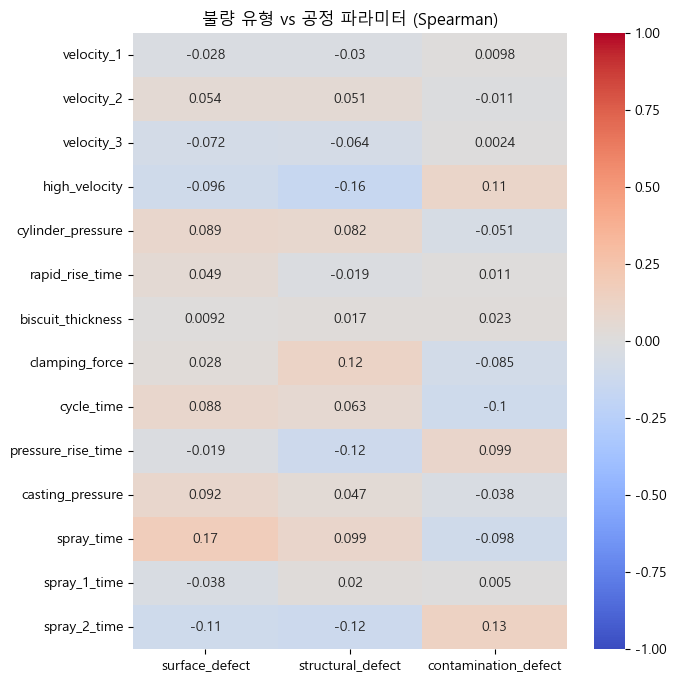

<Sensor vs Defects>


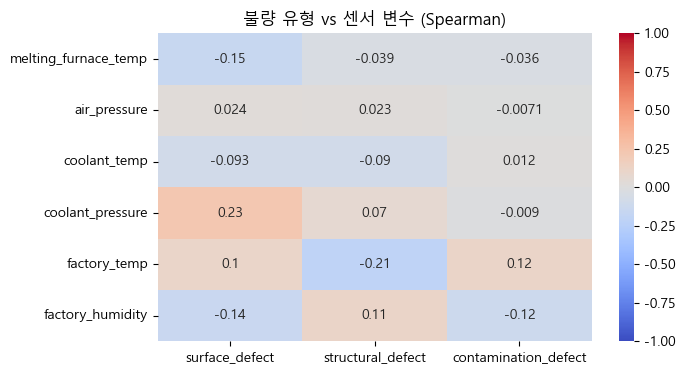

In [25]:
process_cols = [
    'velocity_1', 'velocity_2', 'velocity_3',
    'high_velocity', 'cylinder_pressure', 'rapid_rise_time',
    'biscuit_thickness', 'clamping_force', 'cycle_time',
    'pressure_rise_time', 'casting_pressure', 'spray_time',
    'spray_1_time', 'spray_2_time'
]

sensor_cols = [
    'melting_furnace_temp', 'air_pressure', 'coolant_temp',
    'coolant_pressure', 'factory_temp', 'factory_humidity'
]

target_cols = ["surface_defect", "structural_defect", "contamination_defect"]

# 1. 공정 변수 vs 불량
corr_process = df_clean[process_cols + target_cols].corr(method="spearman").loc[process_cols, target_cols]

print("<Process vs Defects>")
plt.figure(figsize=(7, 8))
sns.heatmap(corr_process, annot=True, cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("불량 유형 vs 공정 파라미터 (Spearman)")
plt.show()


# 2. 센서 변수 vs 불량
corr_sensor = df_clean[sensor_cols + target_cols].corr(method="spearman").loc[sensor_cols, target_cols]

print("<Sensor vs Defects>")
plt.figure(figsize=(7, 4))
sns.heatmap(corr_sensor, annot=True, cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("불량 유형 vs 센서 변수 (Spearman)")
plt.show()

### 2.9.2 극단값 분포 확인_process

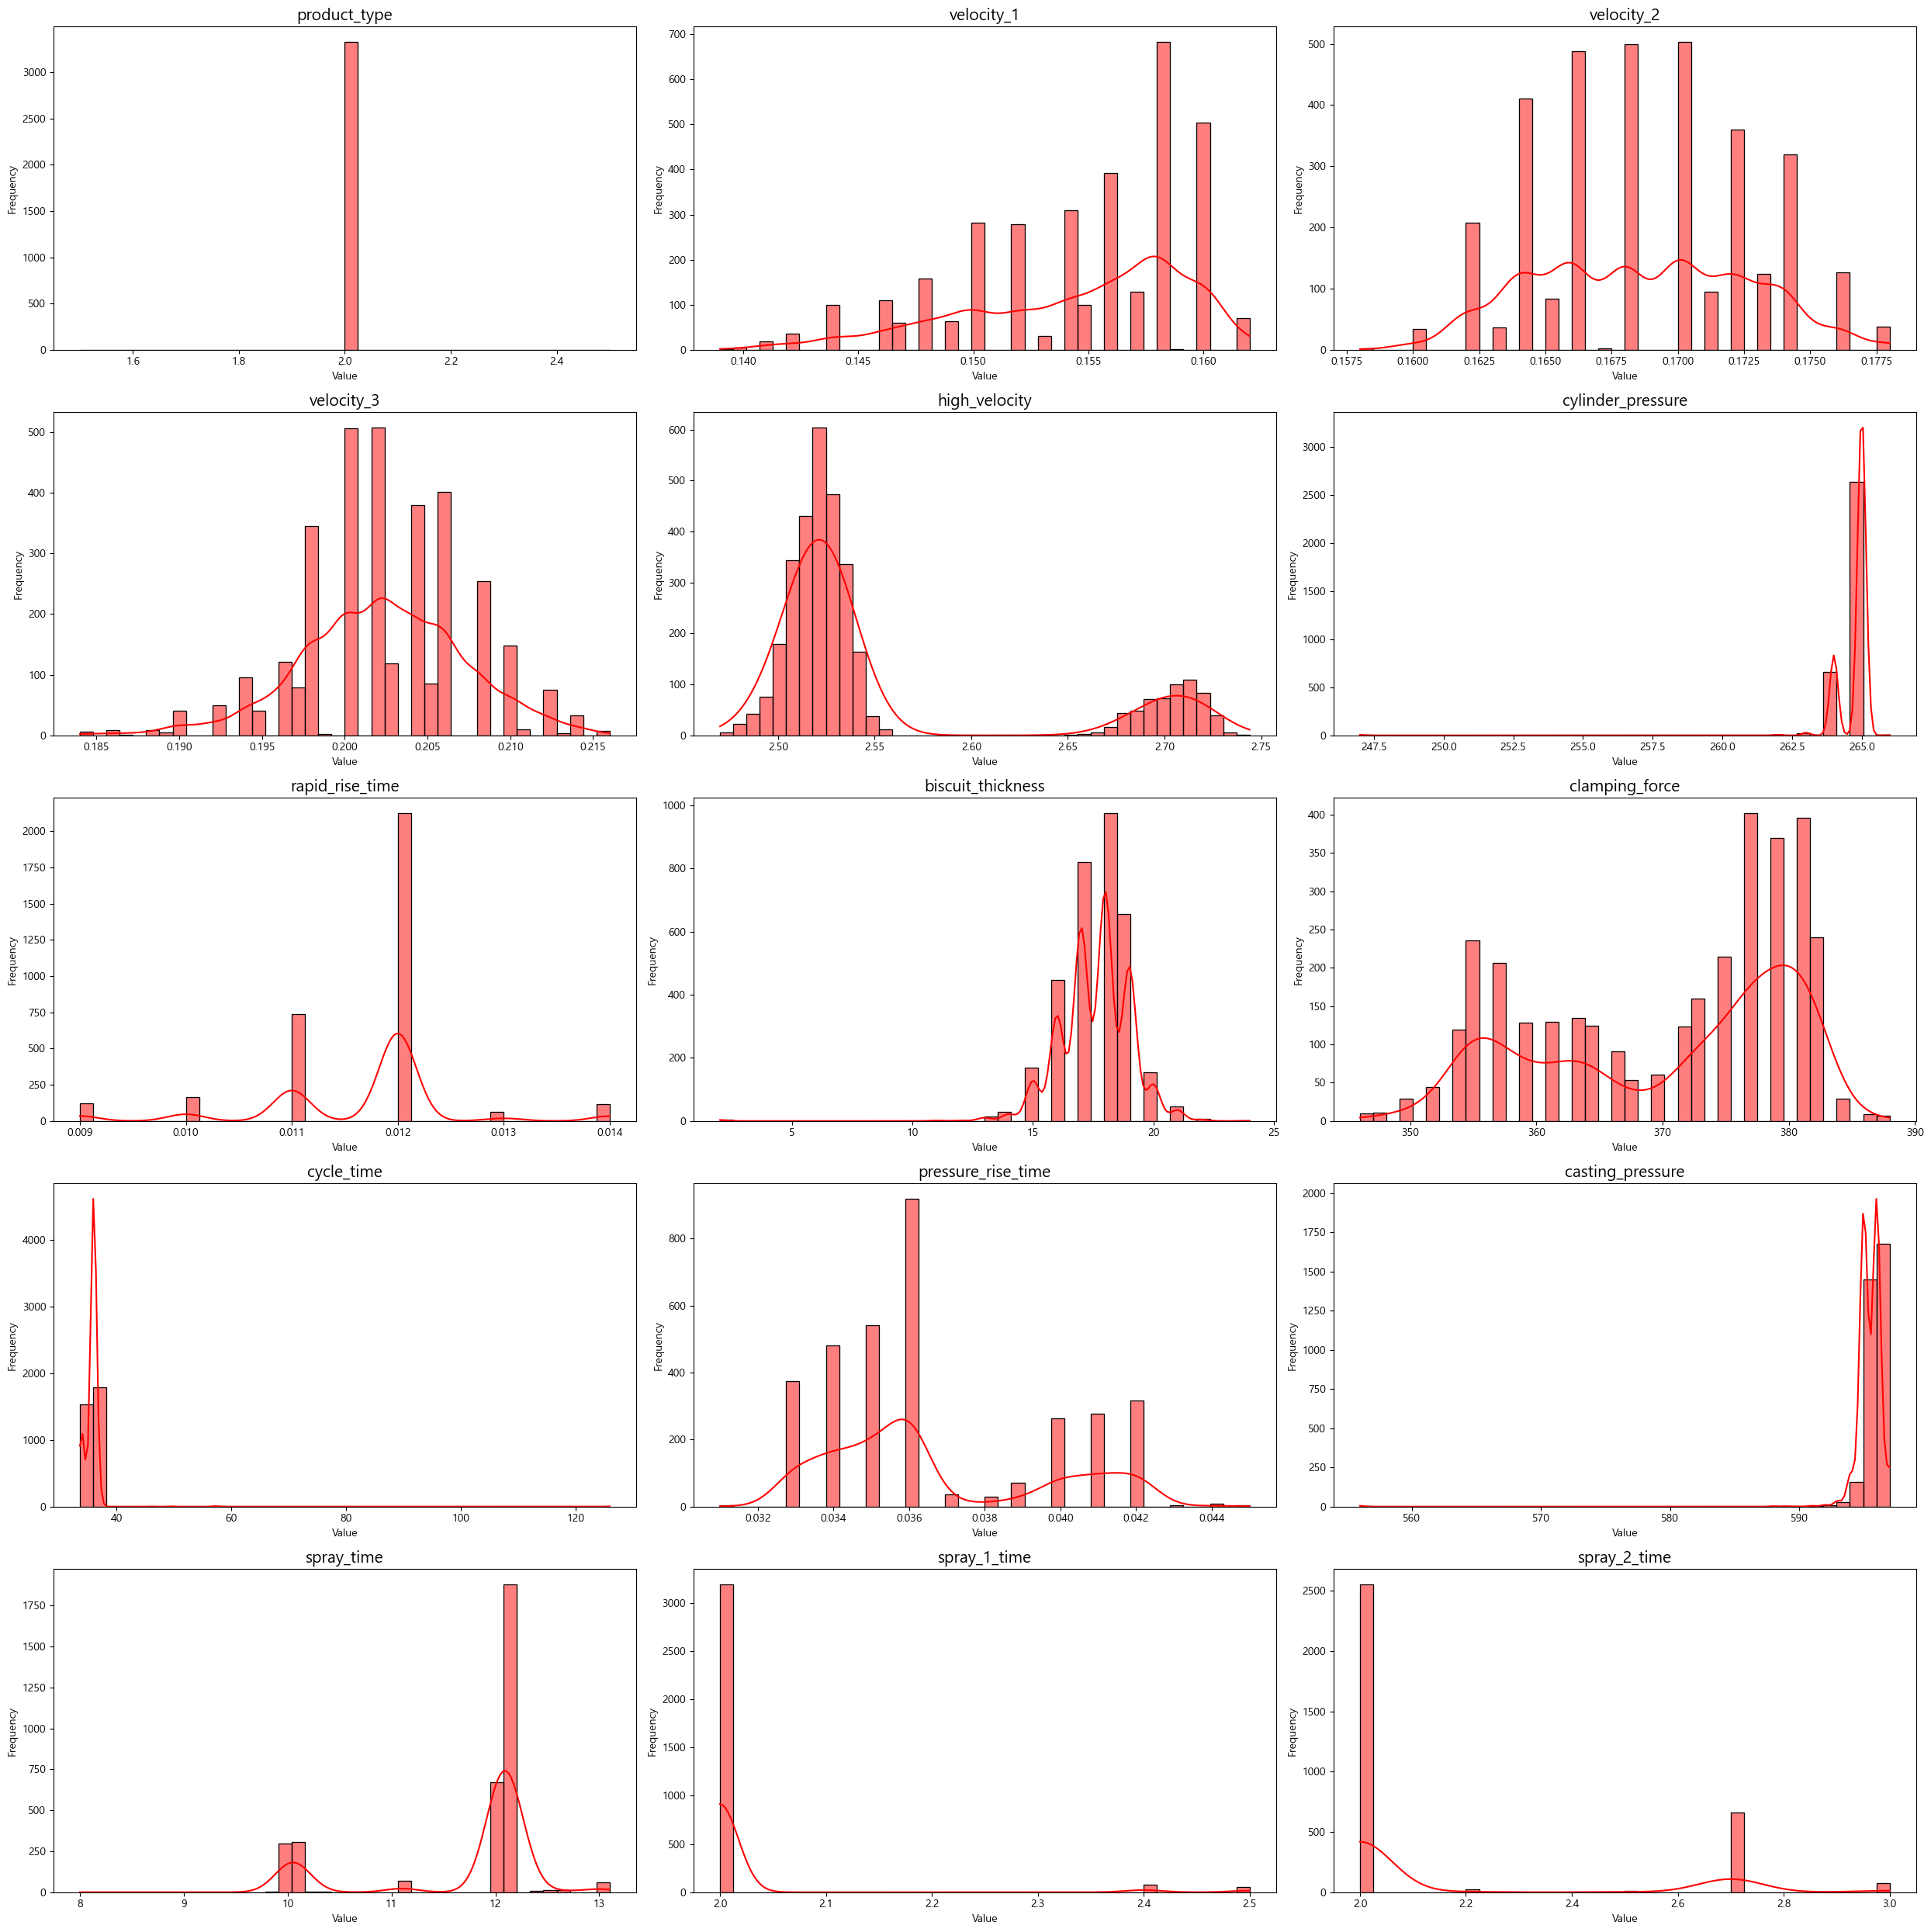

In [26]:
# 1. 수치형 컬럼
numeric_cols = df_process_clean.select_dtypes(include=['number']).columns
n_cols = 3
n_rows = (len(numeric_cols) - 1) // n_cols + 1

plt.figure(figsize=(25, n_rows * 5))
plt.subplots_adjust(hspace=0.4)

for i, col_name in enumerate(numeric_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.histplot(df_process_clean[col_name], kde=True, color='red', bins=40)
    plt.title(f'{col_name}', fontsize=15)
    plt.xlabel('Value')
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

### Process 테이블의 각 컬럼에 대해 IQR 방식을 이용하여 이상치 탐지 확인 (Product_Type, Cycle_Time 제외)

In [27]:
# 1. 컬럼 선택
df_process_numeric = df_process_clean.select_dtypes(include=['number'])
df_process_numeric = df_process_numeric.drop(columns=['product_type'], errors='ignore')
col = df_process_numeric.columns

# 2. 이상치 개수를 저장할 딕셔너리
outlier_counts = {}

for col in df_process_numeric.columns:
    Q1 = df_process_numeric[col].quantile(0.25)
    Q3 = df_process_numeric[col].quantile(0.75)
    IQR = Q3 - Q1
    
    # 임계값 계산
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # 이상치 판정 및 개수 합산
    outliers = df_process_numeric[(df_process_numeric[col] < lower_bound) | (df_process_numeric[col] > upper_bound)]
    outlier_counts[col] = len(outliers)

# 3. 결과 출력
outlier_summary = pd.Series(outlier_counts).sort_values(ascending=False)
print(outlier_summary)

# 4. 비율 확인
outlier_ratio = (outlier_summary / len(df_process_clean) * 100).round(2)
print("\n--- 전체 데이터 대비 이상치 비율 (%) ---")
print(outlier_ratio.head(10))

spray_2_time          777
spray_time            776
cycle_time            763
cylinder_pressure     689
high_velocity         608
rapid_rise_time       236
spray_1_time          136
velocity_3             76
casting_pressure       49
velocity_1             24
biscuit_thickness      23
velocity_2              0
pressure_rise_time      0
clamping_force          0
dtype: int64

--- 전체 데이터 대비 이상치 비율 (%) ---
spray_2_time         23.35
spray_time           23.32
cycle_time           22.93
cylinder_pressure    20.70
high_velocity        18.27
rapid_rise_time       7.09
spray_1_time          4.09
velocity_3            2.28
casting_pressure      1.47
velocity_1            0.72
dtype: float64


### 분포도와 비교해서 보기 위한 이상치(Process)를 값을 기준으로 내림차순 정렬한 뒤 상위 10개만 출력 (head값만 조정해서 출력 가능)

In [28]:
# 결과를 저장할 딕셔너리
top_10_outliers = {}

for col in df_process_numeric.columns:
    Q1 = df_process_numeric[col].quantile(0.25)
    Q3 = df_process_numeric[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # 이상치 행만 필터링
    outliers_df = df_process_numeric[(df_process_numeric[col] < lower_bound) | (df_process_numeric[col] > upper_bound)]
    
    if not outliers_df.empty:
        # 해당 컬럼의 이상치들을 내림차순 정렬 후 상위 10개만 저장
        top_10_outliers[col] = outliers_df[col].sort_values(ascending=False).head(10).values

# --- 결과 출력 ---
print("### 각 컬럼별 이상치 내림차순 TOP 10 ###")
print("-" * 50)

for col, values in top_10_outliers.items():
    print(f"컬럼명 : {col}")
    print(f"상위 10개 값: {values}")
    print("-" * 50)

### 각 컬럼별 이상치 내림차순 TOP 10 ###
--------------------------------------------------
컬럼명 : velocity_1
상위 10개 값: [0.141 0.141 0.141 0.141 0.141 0.141 0.141 0.141 0.141 0.141]
--------------------------------------------------
컬럼명 : velocity_3
상위 10개 값: [0.216 0.216 0.216 0.216 0.216 0.216 0.216 0.19  0.19  0.19 ]
--------------------------------------------------
컬럼명 : high_velocity
상위 10개 값: [2.744 2.733 2.733 2.732 2.732 2.732 2.732 2.73  2.73  2.73 ]
--------------------------------------------------
컬럼명 : cylinder_pressure
상위 10개 값: [266 266 264 264 264 264 264 264 264 264]
--------------------------------------------------
컬럼명 : rapid_rise_time
상위 10개 값: [0.014 0.014 0.014 0.014 0.014 0.014 0.014 0.014 0.014 0.014]
--------------------------------------------------
컬럼명 : biscuit_thickness
상위 10개 값: [24 13 13 13 13 13 13 13 13 13]
--------------------------------------------------
컬럼명 : cycle_time
상위 10개 값: [125.9 125.9  57.2  57.2  57.2  57.2  49.5  49.5  46.   37.1]
------------------

### 2.9.3 극단값 분포 확인_sensor

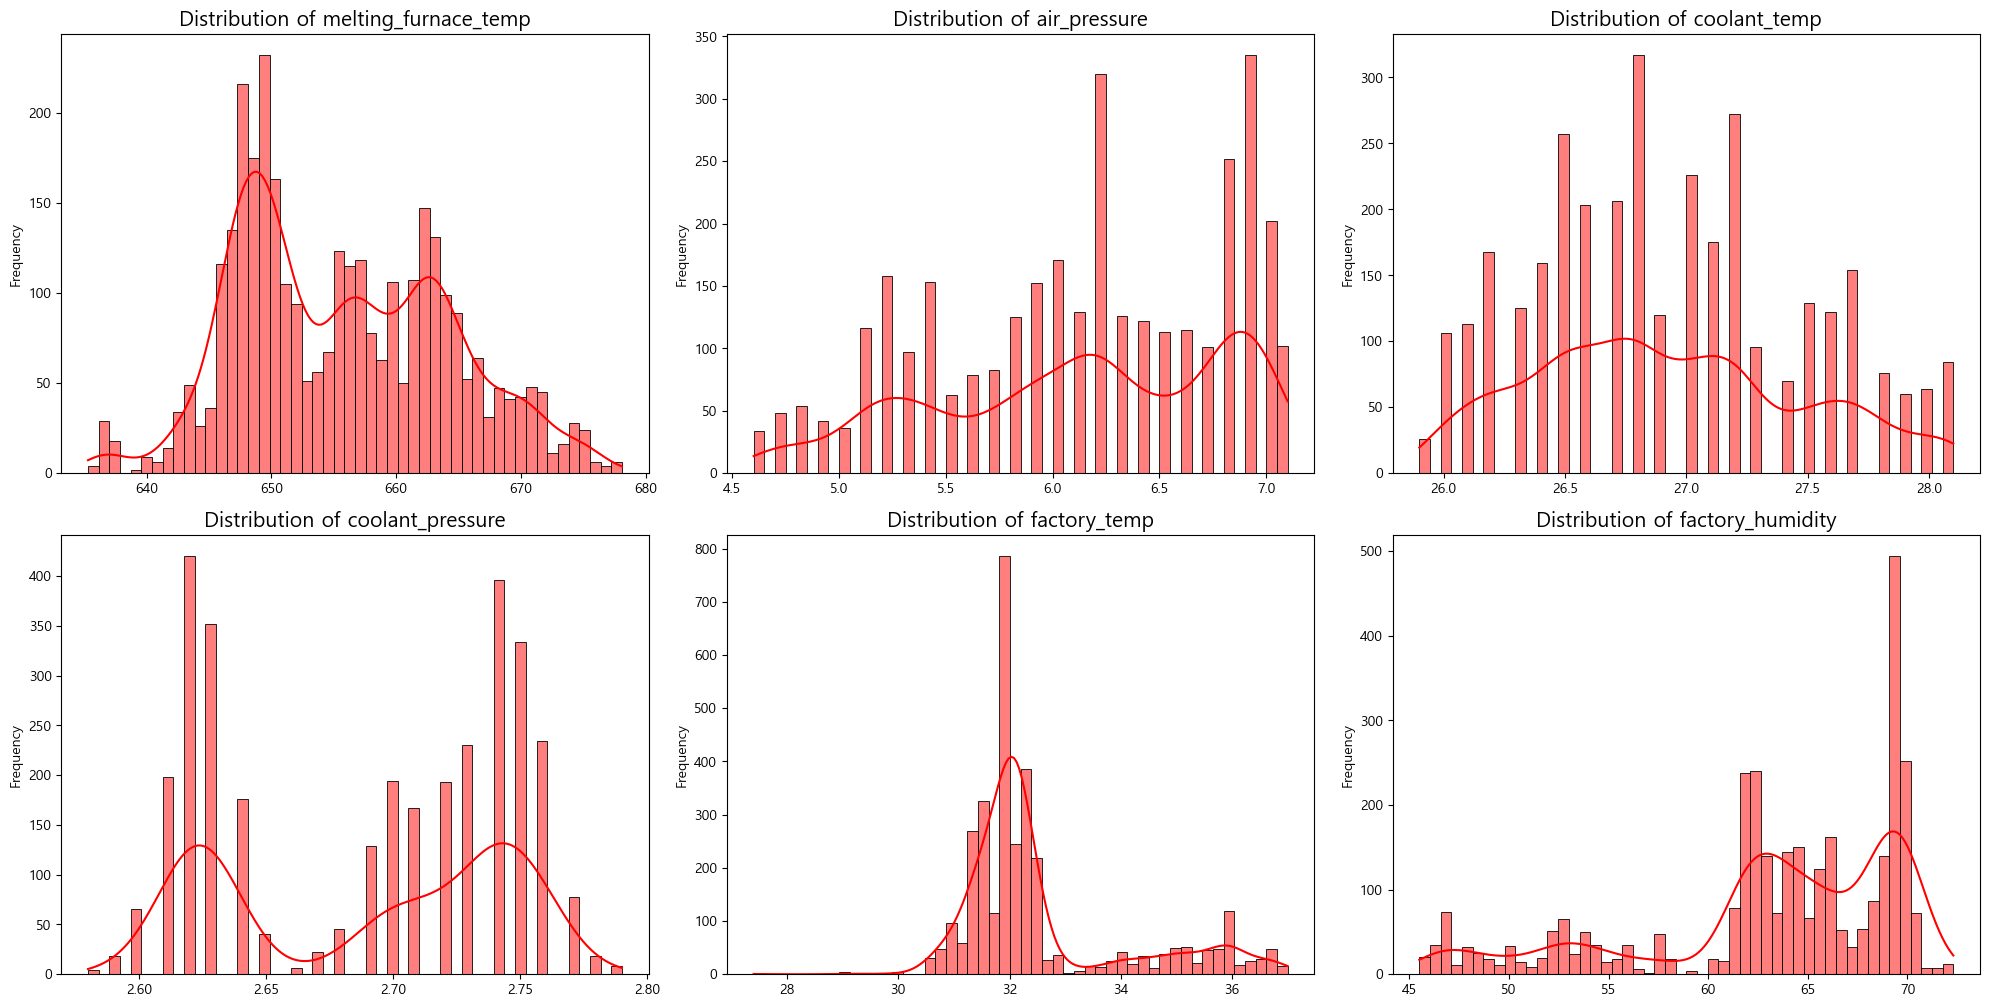

In [29]:
# 1. 수치형 컬럼 추출
numeric_cols = df_sensor_clean.select_dtypes(include=['number']).columns

# 2. 레이아웃 계산
n_cols = 3
n_rows = (len(numeric_cols) - 1 // n_cols + 1)

# 3. 시각화 설정 (figsize는 데이터 컬럼 수에 따라 조절)
plt.figure(figsize=(20, n_rows * 5)) 
plt.subplots_adjust(hspace=0.4)

for i, col in enumerate(numeric_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    # 수치 데이터만 들어가므로 안전하게 히스토그램 생성
    sns.histplot(df_sensor_clean[col], kde=True, color='red', bins=50)
    plt.title(f'Distribution of {col}', fontsize=15)
    plt.xlabel('') # x축 라벨 생략하여 깔끔하게 표시
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

### Sensor 테이블의 각 컬럼에 대해 IQR 방식을 이용하여 이상치 탐지 확인

In [30]:
# 1. 컬럼 선택
df_sensor_numeric = df_sensor_clean.select_dtypes(include=['number'])
col = df_sensor_numeric.columns

# 2. 이상치 개수를 저장할 딕셔너리
outlier_counts = {}

for col in df_sensor_numeric.columns:
    Q1 = df_sensor_numeric[col].quantile(0.25)
    Q3 = df_sensor_numeric[col].quantile(0.75)
    IQR = Q3 - Q1
    
    # 임계값 계산
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # 이상치 판정 및 개수 합산
    outliers = df_sensor_numeric[(df_sensor_numeric[col] < lower_bound) | (df_sensor_numeric[col] > upper_bound)]
    outlier_counts[col] = len(outliers)

# 3. 결과 출력
outlier_summary = pd.Series(outlier_counts).sort_values(ascending=False)
print(outlier_summary)

# 4. 비율 확인
outlier_ratio = (outlier_summary / len(df_process_clean) * 100).round(2)
print("\n--- 전체 데이터 대비 이상치 비율 (%) ---")
print(outlier_ratio.head(10))

factory_temp            641
factory_humidity        274
air_pressure              0
melting_furnace_temp      0
coolant_pressure          0
coolant_temp              0
dtype: int64

--- 전체 데이터 대비 이상치 비율 (%) ---
factory_temp            19.26
factory_humidity         8.23
air_pressure             0.00
melting_furnace_temp     0.00
coolant_pressure         0.00
coolant_temp             0.00
dtype: float64


### 분포도와 비교해서 보기 위한 이상치(Sensor)를 값을 기준으로 내림차순 정렬한 뒤 상위 10개만 출력 (head값만 조정해서 출력 가능)

In [31]:
# 결과를 저장할 딕셔너리
top_10_outliers = {}

for col in df_sensor_numeric.columns:
    Q1 = df_sensor_numeric[col].quantile(0.25)
    Q3 = df_sensor_numeric[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # 이상치 행만 필터링
    outliers_df = df_sensor_numeric[(df_sensor_numeric[col] < lower_bound) | (df_sensor_numeric[col] > upper_bound)]
    
    if not outliers_df.empty:
        # 해당 컬럼의 이상치들을 내림차순 정렬 후 상위 10개만 저장
        top_10_outliers[col] = outliers_df[col].sort_values(ascending=False).head(10).values

# --- 결과 출력 ---
print("### 각 컬럼별 이상치 내림차순 TOP 10 ###")
print("-" * 50)

for col, values in top_10_outliers.items():
    print(f"컬럼명 : {col}")
    print(f"상위 10개 값: {values}")
    print("-" * 50)

### 각 컬럼별 이상치 내림차순 TOP 10 ###
--------------------------------------------------
컬럼명 : factory_temp
상위 10개 값: [37.  37.  37.  37.  37.  37.  37.  37.  37.  36.9]
--------------------------------------------------
컬럼명 : factory_humidity
상위 10개 값: [50.8 50.8 50.8 50.7 50.6 50.6 50.5 50.5 50.5 50.5]
--------------------------------------------------


### 2.9.4 불량 유형 값 분포 확인

In [32]:
target_cols = ["surface_defect", "structural_defect", "contamination_defect"]

for col in target_cols:
    print(f"[{col}]")
    print(df_clean[col].value_counts().sort_index())
    print()

[surface_defect]
surface_defect
0    3132
1     196
Name: count, dtype: int64

[structural_defect]
structural_defect
0    2550
1     778
Name: count, dtype: int64

[contamination_defect]
contamination_defect
0    3309
1      19
Name: count, dtype: int64



### 특정 온도(factory_temp) 이상 불량 여부 확인

In [33]:
temp_over = df_clean[df_clean["factory_temp"] > 32.50].copy()
defect_cols = ["surface_defect", "structural_defect", "contamination_defect"]

# 전체 개수
total = len(temp_over)
print("조건에 맞는 행 개수:", total)
print()

# 각 불량별 개수(=1인 개수), 비율(=1인 비율)
for col in defect_cols:
    count_1 = (temp_over[col] == 1).sum()
    ratio_1 = (temp_over[col] == 1).mean() * 100

    print(f"[{col}]")
    print("개수:", count_1)
    print("비율:", round(ratio_1, 2), "%")
    print()

조건에 맞는 행 개수: 740

[surface_defect]
개수: 14
비율: 1.89 %

[structural_defect]
개수: 48
비율: 6.49 %

[contamination_defect]
개수: 19
비율: 2.57 %



### 특정 습도(factory_humidity) 이상 불량 여부 확인

In [34]:
temp_over = df_clean[df_clean["factory_humidity"] > 32.50].copy()
defect_cols = ["surface_defect", "structural_defect", "contamination_defect"]

# 전체 개수
total = len(temp_over)
print("조건에 맞는 행 개수:", total)
print()

# 각 불량별 개수(=1인 개수), 비율(=1인 비율)
for col in defect_cols:
    count_1 = (temp_over[col] == 1).sum()
    ratio_1 = (temp_over[col] == 1).mean() * 100

    print(f"[{col}]")
    print("개수:", count_1)
    print("비율:", round(ratio_1, 2), "%")
    print()

조건에 맞는 행 개수: 3238

[surface_defect]
개수: 196
비율: 6.05 %

[structural_defect]
개수: 756
비율: 23.35 %

[contamination_defect]
개수: 19
비율: 0.59 %



### z-score 방식으로 이상치 확인

In [35]:
# 1. 숫자형 컬럼만 선택
df_sensor_numeric = df_sensor_clean.select_dtypes(include=['number'])
col = df_sensor_numeric.columns

# 2. 이상치 개수를 저장할 딕셔너리
z_outlier_counts = {}

for col in df_sensor_numeric.columns:
    mean = df_sensor_numeric[col].mean()
    std = df_sensor_numeric[col].std()

    # z-score 계산
    z_score = (df_sensor_numeric[col] - mean) / std

    # |z| > 3 이면 이상치
    outliers = df_sensor_numeric[abs(z_score) > 3]
    z_outlier_counts[col] = len(outliers)

# 3. 결과 출력
z_outlier_summary = pd.Series(z_outlier_counts).sort_values(ascending=False)
print(z_outlier_summary)

# 4. 비율 확인
z_outlier_ratio = (z_outlier_summary / len(df_sensor_clean) * 100).round(2)
print("\n--- 전체 데이터 대비 이상치 비율 (%) ---")
print(z_outlier_ratio.head(10))

factory_temp            2
melting_furnace_temp    0
air_pressure            0
coolant_temp            0
coolant_pressure        0
factory_humidity        0
dtype: int64

--- 전체 데이터 대비 이상치 비율 (%) ---
factory_temp            0.06
melting_furnace_temp    0.00
air_pressure            0.00
coolant_temp            0.00
coolant_pressure        0.00
factory_humidity        0.00
dtype: float64


In [36]:
# 결과를 저장할 딕셔너리
top_10_z_outliers = {}

for col in df_sensor_numeric.columns:
    mean = df_sensor_numeric[col].mean()
    std = df_sensor_numeric[col].std()
    
    # z-score 계산
    z_score = (df_sensor_numeric[col] - mean) / std
    
    # |z| > 3 인 이상치 행만 필터링
    outliers_df = df_sensor_numeric[abs(z_score) > 3]
    
    if not outliers_df.empty:
        # 해당 컬럼의 이상치들을 내림차순 정렬 후 상위 10개만 저장
        top_10_z_outliers[col] = outliers_df[col].sort_values(ascending=False).head(10).values

# --- 결과 출력 ---
print("### 각 컬럼별 Z-score 이상치 내림차순 TOP 10 ###")
print("-" * 50)

for col, values in top_10_z_outliers.items():
    print(f"컬럼명 : {col}")
    print(f"상위 10개 값: {values}")
    print("-" * 50)

### 각 컬럼별 Z-score 이상치 내림차순 TOP 10 ###
--------------------------------------------------
컬럼명 : factory_temp
상위 10개 값: [27.4 27.4]
--------------------------------------------------


결론:\
product_type_1과 교차검증 결과 온도/습도의 값 분포가 비슷하기 때문에 극단값을 이상치로 결론짓긴 무리가 있다고 판단\
sensor 테이블의 factory_temp와 factory_humidity는 따로 이상치 처리를 하지 않기로 결정

### cycle_time 확인

In [37]:
df_clean.sort_values(by="cycle_time", ascending=False).head(20)

,shot_key,product_type,velocity_1,velocity_2,velocity_3,high_velocity,cylinder_pressure,rapid_rise_time,biscuit_thickness,clamping_force,cycle_time,pressure_rise_time,casting_pressure,spray_time,spray_1_time,spray_2_time,melting_furnace_temp,air_pressure,coolant_temp,coolant_pressure,factory_temp,factory_humidity,surface_defect,structural_defect,contamination_defect
5715,5715457_457,2,0.152,0.173,0.202,2.529,263,0.012,19,372,125.9,0.037,592,12.1,2.0,2.0,650.6,5.6,26.8,2.71,32.4,62.2,0,0,0
5716,5716457_457,2,0.152,0.173,0.202,2.529,263,0.012,19,372,125.9,0.037,592,12.1,2.0,2.0,650.6,5.6,26.8,2.71,32.4,62.2,0,0,0
7385,7385577_577,2,0.158,0.170,0.198,2.534,264,0.012,17,359,57.2,0.036,594,12.1,2.0,2.0,659.0,6.9,27.9,2.64,32.3,68.9,0,0,0
7388,7388578_578,2,0.158,0.170,0.198,2.534,264,0.012,17,359,57.2,0.036,594,12.1,2.0,2.0,671.2,6.6,28.0,2.64,32.0,69.6,0,0,0
7387,7387578_578,2,0.158,0.170,0.198,2.534,264,0.012,17,359,57.2,0.036,594,12.1,2.0,2.0,671.2,6.6,28.0,2.64,32.0,69.6,0,0,0
7386,7386577_577,2,0.158,0.170,0.198,2.534,264,0.012,17,359,57.2,0.036,594,12.1,2.0,2.0,659.0,6.9,27.9,2.64,32.3,68.9,0,0,0
5196,5196197_197,2,0.160,0.174,0.206,2.481,264,0.012,18,375,49.5,0.042,595,12.2,2.0,2.0,650.7,6.4,26.3,2.75,31.6,63.2,0,0,0
5195,5195197_197,2,0.160,0.174,0.206,2.481,264,0.012,18,375,49.5,0.042,595,12.2,2.0,2.0,650.7,6.4,26.3,2.75,31.6,63.2,0,0,0
4528,4528335_335,2,0.148,0.170,0.196,2.692,265,0.011,15,354,46.0,0.039,595,10.1,2.0,2.7,647.8,6.2,26.8,2.69,35.8,48.1,0,0,0
4250,4250054_54,2,0.158,0.168,0.202,2.723,264,0.011,14,355,37.1,0.040,594,13.0,2.5,2.7,664.3,6.0,26.2,2.69,33.7,55.6,0,0,0


### 이상치 처리 결론
z-score 병행 = 왜도 < |2| 첨도 < |8| 만족 못할시 iqr

처리 방법은 z-score, iqr 모두 클램핑 기법으로 시행

### 2.9.5 플래깅

In [38]:
# 플래깅 IQR만
# def flag_outliers_iqr(df):
#     """IQR 방식 플래깅, 전체 데이터 프레임에 적용"""
    
#     df_flagged = df.copy()
    
#     numeric_cols = df.select_dtypes(include=["number"]).columns # 숫자형 컬럼만 선택
    
#     for column in numeric_cols:
#         Q1 = df[column].quantile(0.25)
#         Q3 = df[column].quantile(0.75)
#         IQR = Q3 - Q1
    
#         lower_bound = Q1 - 1.5 * IQR
#         upper_bound = Q3 + 1.5 * IQR
    
#         # 1-1. 플래깅 컬럼 추가(이상치라면 1, IQR 범위 내에 속한다면 0)
#         df_flagged[f'{column}_outlier_flag'] = (
#             (df[column] < lower_bound) | (df[column] > upper_bound) # OR연산으로 조건 추가
#         ).astype(int) # True, False가 1/0으로 출력
    
#     return df_flagged


In [39]:
# 1. 함수 정의
def flag_outliers(df, skew_holder = 2, kurt_holder = 8):
    """
    왜도 < |2| AND 첨도 < |8| → Z-score 3σ 방식
    둘 중 하나라도 미충족 → IQR 방식
    """

    df_flagged = df.copy()
    numeric_cols = df.select_dtypes(include=["number"]).columns # 숫자형 컬럼만 선택


    for column in numeric_cols:
        skew_value = df[column].skew()
        kurt_value = df[column].kurt()

        if abs(skew_value) < skew_holder and abs(kurt_value) < kurt_holder:
            # Z-score; 3σ 방식
            mean = df[column].mean()
            std = df[column].std(ddof=0)
            df_flagged[f'{column}_outlier_flag'] = (
                # "df[column] - mean"(=편차)의 결과에 절댓값을 씌우고, 표준편차의 3배 이상이면 이상치로 정의
                (df[column] - mean).abs() > 3 * std
            ).astype(int)

        else:
            # IQR 방식
            Q1 = df[column].quantile(0.25)
            Q3 = df[column].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            df_flagged[f'{column}_outlier_flag'] = (
                (df[column] < lower_bound) | (df[column] > upper_bound)
            ).astype(int)

    return df_flagged

In [40]:
# 2. 함수 실행
df_process_flagged = flag_outliers(df_process_clean)

print('='*30)
print("<Process 관련 변수의 데이터프레임(컬럼추가)>")
print('='*30)
display(df_process_flagged.columns)



<Process 관련 변수의 데이터프레임(컬럼추가)>


Index(['shot_key', 'product_type', 'velocity_1', 'velocity_2', 'velocity_3',
       'high_velocity', 'cylinder_pressure', 'rapid_rise_time',
       'biscuit_thickness', 'clamping_force', 'cycle_time',
       'pressure_rise_time', 'casting_pressure', 'spray_time', 'spray_1_time',
       'spray_2_time', 'product_type_outlier_flag', 'velocity_1_outlier_flag',
       'velocity_2_outlier_flag', 'velocity_3_outlier_flag',
       'high_velocity_outlier_flag', 'cylinder_pressure_outlier_flag',
       'rapid_rise_time_outlier_flag', 'biscuit_thickness_outlier_flag',
       'clamping_force_outlier_flag', 'cycle_time_outlier_flag',
       'pressure_rise_time_outlier_flag', 'casting_pressure_outlier_flag',
       'spray_time_outlier_flag', 'spray_1_time_outlier_flag',
       'spray_2_time_outlier_flag'],
      dtype='object')

In [41]:
# 2. 함수 실행
df_sensor_flagged = flag_outliers(df_sensor_clean)

print('='*30)
print("<Process 관련 변수의 데이터프레임(컬럼추가)>")
print('='*30)
display(df_sensor_flagged.columns)


<Process 관련 변수의 데이터프레임(컬럼추가)>


Index(['melting_furnace_temp', 'air_pressure', 'coolant_temp',
       'coolant_pressure', 'factory_temp', 'factory_humidity',
       'melting_furnace_temp_outlier_flag', 'air_pressure_outlier_flag',
       'coolant_temp_outlier_flag', 'coolant_pressure_outlier_flag',
       'factory_temp_outlier_flag', 'factory_humidity_outlier_flag'],
      dtype='object')

### 2.9.6 이상치가 존재하는 컬럼 (IQR 기준)
- 이상치가 1개 이상 존재하는 컬럼 외엔 플래깅 컬럼 삭제

In [42]:
# 1. 이상치가 존재하지 않는 컬럼 삭제(Process 관련 데이터)

cols_to_drop = [
    col for col in df_process_flagged.columns 
    if col.endswith('_outlier_flag') and df_process_flagged[col].sum() == 0
]

df_process_final = df_process_flagged.drop(columns=cols_to_drop)

display(df_process_final.columns)

Index(['shot_key', 'product_type', 'velocity_1', 'velocity_2', 'velocity_3',
       'high_velocity', 'cylinder_pressure', 'rapid_rise_time',
       'biscuit_thickness', 'clamping_force', 'cycle_time',
       'pressure_rise_time', 'casting_pressure', 'spray_time', 'spray_1_time',
       'spray_2_time', 'velocity_1_outlier_flag', 'velocity_3_outlier_flag',
       'cylinder_pressure_outlier_flag', 'rapid_rise_time_outlier_flag',
       'biscuit_thickness_outlier_flag', 'cycle_time_outlier_flag',
       'casting_pressure_outlier_flag', 'spray_time_outlier_flag',
       'spray_1_time_outlier_flag'],
      dtype='object')

In [43]:
# 1-1. 이상치가 존재하는 컬럼 삭제 확인
print(f"삭제된 플래그 컬럼 수: {len(cols_to_drop)}개")
print(f"남은 플래그 컬럼(이상치가 존재하는 컬럼): {[c for c in df_process_final.columns if '_outlier_flag' in c]}")

삭제된 플래그 컬럼 수: 6개
남은 플래그 컬럼(이상치가 존재하는 컬럼): ['velocity_1_outlier_flag', 'velocity_3_outlier_flag', 'cylinder_pressure_outlier_flag', 'rapid_rise_time_outlier_flag', 'biscuit_thickness_outlier_flag', 'cycle_time_outlier_flag', 'casting_pressure_outlier_flag', 'spray_time_outlier_flag', 'spray_1_time_outlier_flag']


In [44]:
cols_to_drop = [
    col for col in df_sensor_flagged.columns 
    if col.endswith('_outlier_flag') and df_sensor_flagged[col].sum() == 0
]

df_sensor_final = df_sensor_flagged.drop(columns=cols_to_drop)

display(df_sensor_final.columns)

Index(['melting_furnace_temp', 'air_pressure', 'coolant_temp',
       'coolant_pressure', 'factory_temp', 'factory_humidity',
       'factory_temp_outlier_flag'],
      dtype='object')

In [45]:
# 2-1. 이상치가 존재하는 컬럼 삭제 확인
print(f"삭제된 플래그 컬럼 수: {len(cols_to_drop)}개")
print(f"남은 플래그 컬럼(이상치가 존재하는 컬럼): {[c for c in df_sensor_final.columns if '_outlier_flag' in c]}")

삭제된 플래그 컬럼 수: 5개
남은 플래그 컬럼(이상치가 존재하는 컬럼): ['factory_temp_outlier_flag']


### 2.9.7 클래핑
- 임계값보다 크거나 작은 값은 각각 상위임계값과 하위임계값으로 대체

In [46]:
# # 1. 함수 정의
# def clamp_iqr(df):
#     """
#     IQR 기준으로 이상치를 클램핑(clip)해서 반환한다. (플래그 없음)
#     - 기본 제외 컬럼: ["Product_Type", "shot_key"]
#     - k: IQR 배수 (기본 1.5)
#     """
#     # 1-1. 기본으로 항상 제외할 컬럼
#     exclude = ["product_Type", "shot_key"]

#     # 1-2. 숫자 컬럼 중 제외 컬럼 빼기(존재하지 않는 컬럼은 자동으로 무시됨)
#     cols = df.select_dtypes("number").columns.difference(exclude)

#     # 1-3. IQR 경계 계산
#     q1 = df[cols].quantile(0.25)
#     q3 = df[cols].quantile(0.75)
#     iqr = q3 - q1
#     low = q1 - 1.5 * iqr
#     high = q3 + 1.5 * iqr

#     # 1-4. 클램핑 적용 (컬럼별 경계값이므로 axis=1)
#     out = df.copy()
#     out[cols] = df[cols].clip(lower=low, upper=high, axis=1)

#     return out

In [47]:
def clamp_iqr(df, skew_holder=2, kurt_holder=8):
    """
    abs(왜도) < 2 AND abs(첨도) < 8 → Z-score 3σ 방식으로 클램핑
    둘 중 하나라도 미충족 → IQR 방식으로 클램핑

    기본 제외 컬럼: ["product_type", "shot_key"]
    """

    df_clamped = df.copy()
    numeric_cols = df.select_dtypes(include=["number"]).columns # 숫자형 컬럼만 선택

    for column in numeric_cols:
        skew_value = df[column].skew()
        kurt_value = df[column].kurt()

        # Z-score; 3σ 방식
        if abs(skew_value) < skew_holder and abs(kurt_value) < kurt_holder:
            mean = df[column].mean()
            std = df[column].std(ddof=0)

            lower_bound = mean - 3 * std
            upper_bound = mean + 3 * std

        # IQR 방식
        else:
            Q1 = df[column].quantile(0.25)
            Q3 = df[column].quantile(0.75)
            IQR = Q3 - Q1

            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR

        # 클램핑 적용
        df_clamped[column] = df[column].clip(lower=lower_bound, upper=upper_bound)

    return df_clamped

In [48]:
# 2. 원본에서 클램핑된 값 만들기 (Process 관련 데이터)
df_process_clamped = clamp_iqr(df_process_clean)

# 2-1. 플래그 컬럼만 clamped에 붙이기
flag_cols = df_process_final.filter(like="_outlier_flag").columns
df_process_iqr = pd.concat([df_process_clamped, df_process_final[flag_cols]], axis=1)

In [49]:
# 2-2. 이상치 개수 확인
display(
    df_process_iqr
    .filter(like="_outlier_flag")
    .sum()
    .sort_values(ascending=False)
    .head(20)
)

cycle_time_outlier_flag           763
cylinder_pressure_outlier_flag    689
spray_1_time_outlier_flag         136
rapid_rise_time_outlier_flag      120
casting_pressure_outlier_flag      49
biscuit_thickness_outlier_flag     23
velocity_3_outlier_flag            15
velocity_1_outlier_flag             2
spray_time_outlier_flag             1
dtype: int64

In [50]:
# 3. 원본에서 클램핑된 값 만들기 (Sensor 관련 데이터)
df_sensor_clamped = clamp_iqr(df_sensor_clean)

# 3-1. 플래그 컬럼만 clamped에 붙이기
flag_cols = df_sensor_final.filter(like="_outlier_flag").columns
df_sensor_iqr = pd.concat([df_sensor_clamped, df_sensor_final[flag_cols]], axis=1)

In [51]:
# 3-2. 이상치 개수 확인
display(
    df_sensor_iqr
    .filter(like="_outlier_flag")
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

factory_temp_outlier_flag    2
dtype: int64

## 3. 데이터 최종 확인 및 통합

### 3.1 데이터 최종 확인

In [52]:
print(df_process_iqr.shape)
df_process_iqr.head()

(3328, 25)


,shot_key,product_type,velocity_1,velocity_2,velocity_3,high_velocity,cylinder_pressure,rapid_rise_time,biscuit_thickness,clamping_force,cycle_time,pressure_rise_time,casting_pressure,spray_time,spray_1_time,spray_2_time,velocity_1_outlier_flag,velocity_3_outlier_flag,cylinder_pressure_outlier_flag,rapid_rise_time_outlier_flag,biscuit_thickness_outlier_flag,cycle_time_outlier_flag,casting_pressure_outlier_flag,spray_time_outlier_flag,spray_1_time_outlier_flag
4207,4207011_11,2,0.156,0.166,0.192,2.723,265,0.012,20,357,36.55,0.041,595.0,12.5,2.0,2.2,0,0,0,0,0,1,0,0,0
4208,4208012_12,2,0.157,0.166,0.204,2.730,265,0.014,19,359,36.50,0.040,594.0,12.5,2.0,2.2,0,0,1,0,0,0,0,0,0
4209,4209013_13,2,0.156,0.170,0.204,2.715,265,0.012,18,361,36.50,0.041,595.0,12.5,2.0,2.2,0,0,0,0,0,0,0,0,0
4210,4210014_14,2,0.154,0.170,0.202,2.717,265,0.011,20,364,36.50,0.042,595.0,12.5,2.0,2.2,0,0,1,0,0,0,0,0,0
4211,4211015_15,2,0.146,0.160,0.198,2.684,265,0.012,20,357,36.50,0.042,595.0,12.5,2.0,2.2,0,0,1,0,0,0,0,0,0


In [53]:
print(df_sensor_iqr.shape)
df_sensor_iqr.head()

(3328, 7)


,melting_furnace_temp,air_pressure,coolant_temp,coolant_pressure,factory_temp,factory_humidity,factory_temp_outlier_flag
4207,671.6,6.5,26.1,2.70,33.2,57.4,0
4208,672.1,6.4,26.2,2.71,33.3,57.0,0
4209,672.4,6.4,26.2,2.70,33.5,56.7,0
4210,672.4,6.4,26.2,2.70,33.5,56.7,0
4211,672.4,6.3,26.2,2.71,33.6,56.4,0


In [54]:
print(df_defects_groups.shape)
df_defects_groups.head()

(3328, 3)


,surface_defect,structural_defect,contamination_defect
4207,0,0,0
4208,0,0,0
4209,0,0,0
4210,0,0,0
4211,0,0,0


### 3.2 머신러닝용 데이터셋 저장 (.csv)

In [55]:
df_clean_2 = pd.concat([df_process_iqr, df_sensor_clean, df_defects_groups], axis=1)
df_clean_2 =df_clean_2.drop(columns=["product_type"])


In [56]:
print(df_clean_2.shape)
df_clean_2.head()

(3328, 33)


,shot_key,velocity_1,velocity_2,velocity_3,high_velocity,cylinder_pressure,rapid_rise_time,biscuit_thickness,clamping_force,cycle_time,pressure_rise_time,casting_pressure,spray_time,spray_1_time,spray_2_time,velocity_1_outlier_flag,velocity_3_outlier_flag,cylinder_pressure_outlier_flag,rapid_rise_time_outlier_flag,biscuit_thickness_outlier_flag,cycle_time_outlier_flag,casting_pressure_outlier_flag,spray_time_outlier_flag,spray_1_time_outlier_flag,melting_furnace_temp,air_pressure,coolant_temp,coolant_pressure,factory_temp,factory_humidity,surface_defect,structural_defect,contamination_defect
4207,4207011_11,0.156,0.166,0.192,2.723,265,0.012,20,357,36.55,0.041,595.0,12.5,2.0,2.2,0,0,0,0,0,1,0,0,0,671.6,6.5,26.1,2.70,33.2,57.4,0,0,0
4208,4208012_12,0.157,0.166,0.204,2.730,265,0.014,19,359,36.50,0.040,594.0,12.5,2.0,2.2,0,0,1,0,0,0,0,0,0,672.1,6.4,26.2,2.71,33.3,57.0,0,0,0
4209,4209013_13,0.156,0.170,0.204,2.715,265,0.012,18,361,36.50,0.041,595.0,12.5,2.0,2.2,0,0,0,0,0,0,0,0,0,672.4,6.4,26.2,2.70,33.5,56.7,0,0,0
4210,4210014_14,0.154,0.170,0.202,2.717,265,0.011,20,364,36.50,0.042,595.0,12.5,2.0,2.2,0,0,1,0,0,0,0,0,0,672.4,6.4,26.2,2.70,33.5,56.7,0,0,0
4211,4211015_15,0.146,0.160,0.198,2.684,265,0.012,20,357,36.50,0.042,595.0,12.5,2.0,2.2,0,0,1,0,0,0,0,0,0,672.4,6.3,26.2,2.71,33.6,56.4,0,0,0


### 3.1 데이터셋 저장 (.csv)

In [57]:
# "../common-file/파일명 지정.csv"

df_clean_2.to_csv("overall_2.csv", index=False)
df_process_clamped.to_csv("process_data_2.csv", index=False)
df_sensor_clean.to_csv("sensor_data_2.csv", index=False)
df_defects_groups.to_csv("defects_data_2.csv", index=False)